# CLIP Baseline Cat Classifier

This notebook builds the baseline classifier for the final DATASCI 447 project. The goal is to test whether pretrained CLIP image embeddings can distinguish between two individual household cats, Tig and Buster, using a small custom image dataset.

The workflow is:

1. Load images from `data/raw/tig` and `data/raw/buster`.
2. Encode each image using pretrained CLIP ViT-B/32 image embeddings.
3. Train a logistic regression classifier on the embeddings.
4. Evaluate the classifier using a balanced validation split, confusion matrix, PCA visualization, repeated cross-validation, and decision-margin plots.

## 1. Setup and Imports

This section loads Python packages, sets the random seed, defines file paths, and selects the available compute device.

In [30]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import clip

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA



## 2. Load Image Paths

Images are organized by class in `data/raw/tig` and `data/raw/buster`. Each folder contains solo images of one cat collected under different poses, lighting conditions, distances, and backgrounds.

In [31]:

# Config
DATA_DIR = Path("data/raw")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
BATCH_SIZE = 32
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

# Load file paths
def get_image_paths(class_dir: Path):
    paths = []
    for p in class_dir.rglob("*"):
        if p.suffix.lower() in IMAGE_EXTS:
            paths.append(p)
    return sorted(paths)

tig_paths = get_image_paths(DATA_DIR / "tig")
buster_paths = get_image_paths(DATA_DIR / "buster")

if len(tig_paths) == 0 or len(buster_paths) == 0:
    raise ValueError(
        "Need images in both data/raw/tig and data/raw/buster before running."
    )

all_paths = tig_paths + buster_paths
labels = np.array([0] * len(tig_paths) + [1] * len(buster_paths))
label_names = {0: "tig", 1: "buster"}

print(f"Tig images: {len(tig_paths)}")
print(f"Buster images: {len(buster_paths)}")
print(f"Total images: {len(all_paths)}")
print(f"Using device: {DEVICE}")


Tig images: 30
Buster images: 30
Total images: 60
Using device: cuda


## 3. Encode Images and Train Classifier with CLIP

I use pretrained CLIP ViT-B/32 as a fixed feature extractor. Each image is converted into a 512-dimensional embedding vector, which serves as the input representation for the downstream classifier.

The classifier is trained on CLIP embeddings instead of raw pixels. I use a stratified train-validation split with an equal number of Tig and Buster images in the validation set.

In [32]:

# Load CLIP
clip_model, clip_preprocess = clip.load("ViT-B/32", device=DEVICE)
clip_model.eval()

# Encode images
def load_image(path: Path):
    img = Image.open(path).convert("RGB")
    return clip_preprocess(img)

def encode_images(paths, batch_size=32):
    features = []
    valid_paths = []

    for i in tqdm(range(0, len(paths), batch_size), desc="Encoding images"):
        batch_paths = paths[i:i+batch_size]
        batch_tensors = []
        for p in batch_paths:
            try:
                batch_tensors.append(load_image(p))
                valid_paths.append(p)
            except Exception as e:
                print(f"Skipping {p}: {e}")

        if not batch_tensors:
            continue

        batch = torch.stack(batch_tensors).to(DEVICE)
        with torch.no_grad():
            feats = clip_model.encode_image(batch)
            feats = feats / feats.norm(dim=-1, keepdim=True)
        features.append(feats.cpu().numpy())

    if not features:
        raise ValueError("No valid images could be encoded.")

    return np.vstack(features), valid_paths

X, valid_paths = encode_images(all_paths, batch_size=BATCH_SIZE)

# If any images failed, realign labels
path_to_label = {str(p): y for p, y in zip(all_paths, labels)}
y = np.array([path_to_label[str(p)] for p in valid_paths])

print(f"Encoded feature matrix shape: {X.shape}")

# Train / validation split
# Use an even validation size so both cats are represented equally.
# images per class when using stratified sampling.
X_train, X_val, y_train, y_val, paths_train, paths_val = train_test_split(
    X, y, valid_paths,
    test_size=16,
    stratify=y,
    random_state=SEED
)

print(f"Train size: {len(y_train)}")
print(f"Validation size: {len(y_val)}")
print("Training class counts:", pd.Series(y_train).map(label_names).value_counts().to_dict())
print("Validation class counts:", pd.Series(y_val).map(label_names).value_counts().to_dict())

# Baseline 1: Logistic regression
clf = LogisticRegression(max_iter=5000, random_state=SEED)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_val)

acc = accuracy_score(y_val, y_pred)
print(f"\nValidation accuracy: {acc:.3f}\n")
print(classification_report(y_val, y_pred, target_names=["tig", "buster"]))


Encoding images: 100%|██████████| 2/2 [00:03<00:00,  1.90s/it]

Encoded feature matrix shape: (60, 512)
Train size: 44
Validation size: 16
Training class counts: {'buster': 22, 'tig': 22}
Validation class counts: {'buster': 8, 'tig': 8}

Validation accuracy: 1.000

              precision    recall  f1-score   support

         tig       1.00      1.00      1.00         8
      buster       1.00      1.00      1.00         8

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



## 4. Confusion Matrix

The confusion matrix shows whether the model confuses Tig and Buster on the held-out validation images.

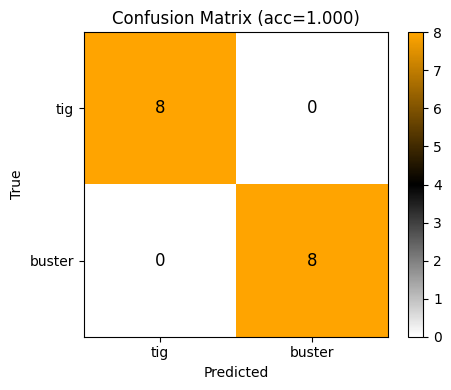

In [33]:
from matplotlib.colors import LinearSegmentedColormap

# Custom colormap: orange -> black -> white
colors = [(1.0, 0.647, 0.0), (0, 0, 0), (1, 1, 1)]  # orange, black, white
custom_cmap = LinearSegmentedColormap.from_list("custom_tig_buster", colors, N=256)

cm = confusion_matrix(y_val, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap=custom_cmap.reversed())
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["tig", "buster"])
ax.set_yticklabels(["tig", "buster"])
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix (acc={acc:.3f})")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=12)
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_gradient.png", dpi=200)
plt.show()

## 5. PCA Visualization of CLIP Embeddings

This figure projects the CLIP image embeddings into two dimensions using PCA. It helps show whether the two cats form visually separable clusters in the representation space.

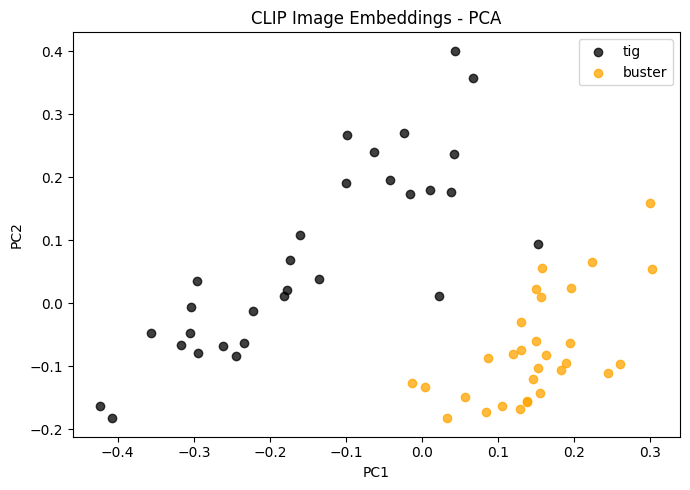

In [34]:
pca = PCA(n_components=2, random_state=SEED)
X_2d = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(7, 5))
for cls in [0, 1]:
    idx = y == cls
    color = 'black' if cls == 0 else 'orange'
    ax.scatter(X_2d[idx, 0], X_2d[idx, 1],
               color=color,
               label=label_names[cls],
               alpha=0.75)

ax.set_title("CLIP Image Embeddings - PCA")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "embedding_pca.png", dpi=200)
plt.show()

## 6. Repeated Cross-Validation

Because the dataset is small, a single train-validation split may be unstable. Repeated stratified cross-validation gives a more robust estimate of classification performance across multiple splits.

Repeated CV mean accuracy: 0.9833333333333333
Repeated CV std: 0.03333333333333335


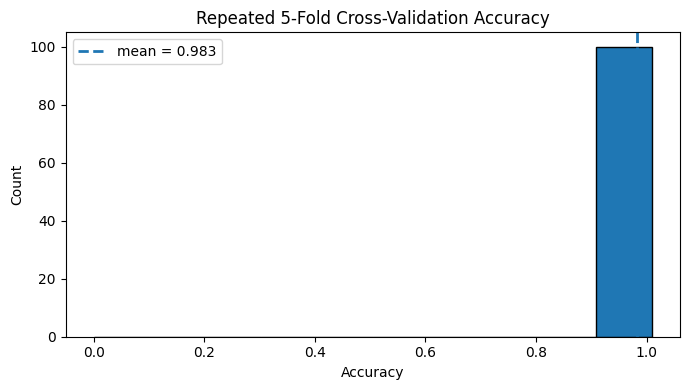

In [35]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=SEED)

cv_scores = cross_val_score(
    LogisticRegression(max_iter=5000, random_state=SEED),
    X, y,
    cv=cv,
    scoring="accuracy"
)

cv_mean = cv_scores.mean()
cv_std = cv_scores.std()

print("Repeated CV mean accuracy:", cv_mean)
print("Repeated CV std:", cv_std)

fig, ax = plt.subplots(figsize=(7, 4))

bins = np.linspace(0, 1.01, 11)
ax.hist(cv_scores, bins=bins, edgecolor="black")
ax.axvline(cv_mean, linestyle="--", linewidth=2, label=f"mean = {cv_mean:.3f}")
ax.set_xlabel("Accuracy")
ax.set_ylabel("Count")
ax.set_title("Repeated 5-Fold Cross-Validation Accuracy")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "repeated_cv_accuracy_hist.png", dpi=200)
plt.show()

## 7. Decision Margins

The decision-margin plot shows how far each validation image is from the logistic regression decision boundary. Larger margins indicate more confident classifications.

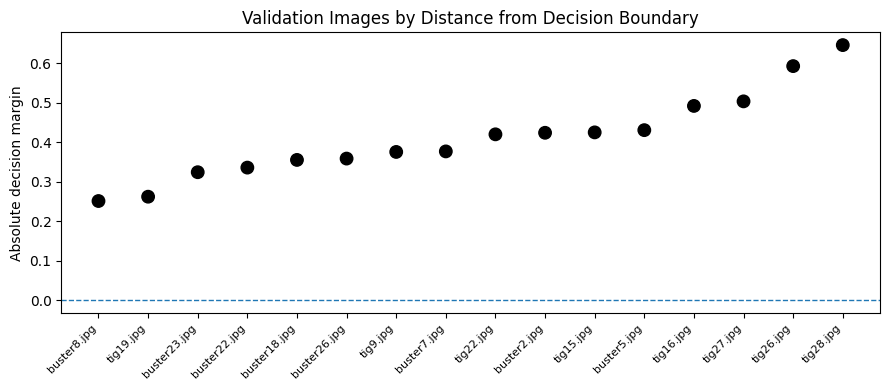

In [36]:
val_margin = clf.decision_function(X_val)

margin_df = pd.DataFrame({
    "image": [p.name for p in paths_val],
    "true_label": [label_names[v] for v in y_val],
    "pred_label": [label_names[v] for v in y_pred],
    "margin": val_margin
})

# absolute distance from decision boundary
margin_df["abs_margin"] = np.abs(margin_df["margin"])
margin_df["correct"] = margin_df["true_label"] == margin_df["pred_label"]
margin_df = margin_df.sort_values("abs_margin")

fig, ax = plt.subplots(figsize=(9, 4))

colors = ["black" if c else "red" for c in margin_df["correct"]]
ax.scatter(range(len(margin_df)), margin_df["abs_margin"], s=80, c=colors)

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xticks(range(len(margin_df)))
ax.set_xticklabels(margin_df["image"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Absolute decision margin")
ax.set_title("Validation Images by Distance from Decision Boundary")

for i, row in enumerate(margin_df.itertuples()):
    if not row.correct:
        ax.annotate("mistake", (i, row.abs_margin), xytext=(0, 8),
                    textcoords="offset points", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "validation_margin_plot.png", dpi=200)
plt.show()

## 8. CLIP Embedding Similarity

The cosine similarity heatmap compares all image embeddings to each other. Stronger within-class similarity suggests that CLIP captures identity-relevant visual structure for the two cats.

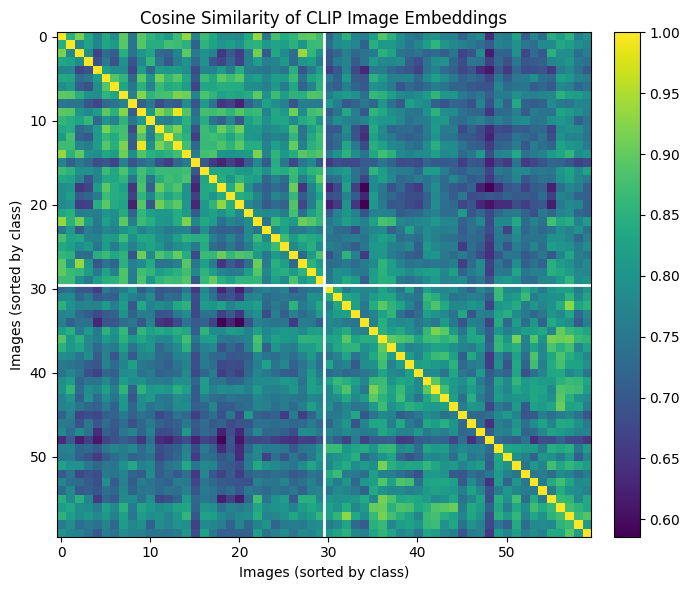

In [37]:
from sklearn.metrics.pairwise import cosine_similarity

sim = cosine_similarity(X)

# sort images by label, then by first PCA coordinate if available
order = np.argsort(y)
sim_sorted = sim[order][:, order]
y_sorted = y[order]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(sim_sorted, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# draw boundary between classes
boundary = np.sum(y_sorted == 0)
ax.axhline(boundary - 0.5, color="white", linewidth=2)
ax.axvline(boundary - 0.5, color="white", linewidth=2)

ax.set_title("Cosine Similarity of CLIP Image Embeddings")
ax.set_xlabel("Images (sorted by class)")
ax.set_ylabel("Images (sorted by class)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "embedding_similarity_heatmap.png", dpi=200)
plt.show()

## 9. Save Summary Files

This final section saves a text summary of the baseline model results and records any validation mistakes.

In [38]:

# Save example mistakes
mistakes = []
for p, true_y, pred_y in zip(paths_val, y_val, y_pred):
    if true_y != pred_y:
        mistakes.append((p, true_y, pred_y))

with open(OUTPUT_DIR / "mistakes.txt", "w") as f:
    for p, true_y, pred_y in mistakes:
        f.write(f"{p} | true={label_names[true_y]} | pred={label_names[pred_y]}\n")

# Save simple summary
with open(OUTPUT_DIR / "summary.txt", "w") as f:
    f.write(f"Tig images: {len(tig_paths)}\n")
    f.write(f"Buster images: {len(buster_paths)}\n")
    f.write(f"Total valid encoded images: {len(y)}\n")
    f.write(f"Validation accuracy: {acc:.4f}\n")
    f.write(f"Repeated CV mean accuracy: {cv_mean:.4f}\n")
    f.write(f"Repeated CV std: {cv_std:.4f}\n")
    f.write(f"PCA variance explained: {pca.explained_variance_ratio_}\n")
    f.write(f"Number of mistakes: {len(mistakes)}\n")

print("\nDone.")
print("Saved:")
print(" - outputs/confusion_matrix_gradient.png")
print(" - outputs/embedding_pca.png")
print(" - outputs/mistakes.txt")
print(" - outputs/summary.txt")


Done.
Saved:
 - outputs/confusion_matrix_gradient.png
 - outputs/embedding_pca.png
 - outputs/mistakes.txt
 - outputs/summary.txt
